# 定理22（H-stage 不変領域）　1次元モデルで見る「入力条件の緩和」

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> **これは原文の定理22の反例ではありません。** 証明に使う「入力条件（H-stage）」を **緩めても結論が成り立つ範囲** を、1次元で具体的に見る例です。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。

## 1. 何の例なのか

### 定理22（原文）と、その証明の「段」

定理22は、**高い抽象度へ上がる階段**（LUB の列 $u_{n+1}=u_n\vee v_{n+1}$：新しい情報・他者の視点を、消さずに包む）を扱います。

$$
u_{n+1}=u_n\vee v_{n+1},\quad p_n>\text{しきい値}_n
\ \Longrightarrow\ u_n\prec u_{n+1},\ \text{指数安定},\ \mathcal F_i(u_n)\le\mathcal F_i(u_{n+1}),\ u_\infty=\bigvee u_n\preceq\top .
$$

各 **段 $n$** では、定理21と同じ「しきい値を超えた臨場感が谷を掘る」議論を使います。そこでは **局所球 $U_n$**（段 $n$ の谷のまわりの領域）の中で、勾配流が出ていかないこと（**不変性**）が必要です。

### 入力条件（H-stage）と、この例が見せる緩和

* **旧条件：** 初期点 $x_0$ から決まる **部分準位集合** $\{\tilde V\le\tilde V(x_0)\}$（初期点よりポテンシャルが低い領域）**全体** が、局所球 $U_n$ の **内部に収まる**（内部障壁）こと。
* **緩和条件：** 局所球の内側にある、**より小さな前向き不変区間** $I$ さえあればよい。ここで「**前向き不変**」とは、一度入ったら出ない、ということです。端点で流れが内向きなら不変です。

緩和条件のほうが **弱い**（満たしやすい）ので、定理22の証明の適用範囲が広がります。この例は、**旧条件が成り立たず、緩和条件が成り立つ具体的なモデル** を1つ示します。

### モデル（1次元）

$$
\tilde V(x)=\frac x2+\frac{x^2}2=\frac12\Bigl(x+\frac12\Bigr)^2-\frac18 ,\qquad x^*=-\frac12\ \text{（谷）},
$$

局所球 $U=[-1,1]$、移動度 $1$、閉ループ $\dot x=-(x+\tfrac12)$（$=-\tilde V'(x)$）、初期点 $x_0=\tfrac12$。

### 記号とコード変数の対応

| 原文の概念 | このモデルでは | コード |
| --- | --- | --- |
| 実効ポテンシャル $\tilde V$ | $x/2+x^2/2$ | `V` |
| 谷 $x^*$ | $-\tfrac12$ | `xstar` |
| 局所球 $U_n$ | $[-1,1]$ | `ball` |
| 初期点 $x_0$ | $\tfrac12$ | `x0` |
| 旧：初期部分準位 $\{\tilde V\le\tilde V(x_0)\}$ | $[x^*-s,\,x^*+s]=[-\tfrac32,\tfrac12]$、$s=\lvert x_0-x^*\rvert=1$ | `sub` |
| 新：前向き不変区間 $I$ | $[-\tfrac12,\tfrac12]$ | `I` |

## 2. なぜこれが「条件緩和の例」と言えるのか

* **旧条件は成り立たない。** 部分準位集合 $[-\tfrac32,\tfrac12]$ の左端 $-\tfrac32$ は、局所球 $[-1,1]$ の **外** にある（$-\tfrac32<-1$）。だから「部分準位集合全体が球の内側」という旧条件は **破れる**。
* **緩和条件は成り立つ。** $I=[-\tfrac12,\tfrac12]$ では、左端 $-\tfrac12$ で $\dot x=-(x+\tfrac12)=0\ge0$、右端 $\tfrac12$ で $\dot x=-1\le0$（**端点で内向き**）なので前向き不変。かつ $I\subset(-1,1)$ で球の内側。
* **軌道は実際に $I$ に留まり、指数収束する。** 厳密解 $x(t)=x^*+(x_0-x^*)e^{-t}$ は $[-\tfrac12,\tfrac12]$ の中にあり、

$$
\tilde V(x(t))-\tilde V(x^*)=e^{-2t}\bigl(\tilde V(x_0)-\tilde V(x^*)\bigr).
$$

## 3. 旧条件と新条件の判定、厳密解

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

V = lambda x: x / 2 + x**2 / 2
xstar, x0, ball = -0.5, 0.5, (-1.0, 1.0)

# 旧: 初期の部分準位集合 {V ≤ V(x0)} (区間 [xstar−s, xstar+s], s=|x0−xstar|)
s = abs(x0 - xstar); sub = (xstar - s, xstar + s)
sublevel_inside_ball = ball[0] < sub[0] and sub[1] < ball[1]
# 新: 前向き不変区間 I=[−½,½]
I = (-0.5, 0.5)
field = lambda x: -(x + 0.5)
invariant = field(I[0]) >= 0 and field(I[1]) <= 0                 # 端点で内向き
I_inside_ball = ball[0] < I[0] and I[1] < ball[1]

t = np.linspace(0, 5, 501); x = xstar + (x0 - xstar) * np.exp(-t)  # 厳密解
gap = V(x) - V(xstar); gap_bound = (V(x0) - V(xstar)) * np.exp(-2 * t)

`sublevel_inside_ball`（旧）、`invariant`・`I_inside_ball`（新）を真偽で出し、厳密解 `x`、$\tilde V$ の差 `gap` と理論値 `gap_bound` を計算します。

## 4. 図を読む

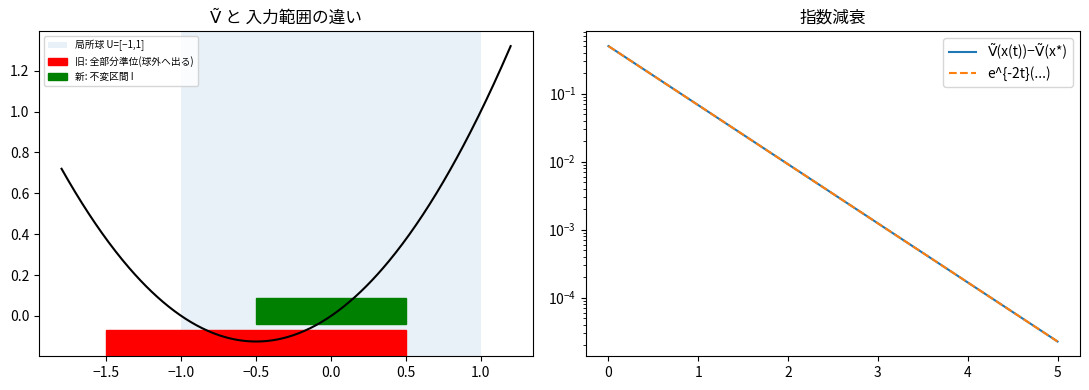

In [2]:
# %% 可視化
xs = np.linspace(-1.8, 1.2, 400)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(xs, V(xs), c="k"); ax[0].axvspan(*ball, alpha=.1, label="局所球 U=[−1,1]")
ax[0].axvspan(*sub, ymin=0, ymax=.08, color="r", label="旧: 全部分準位(球外へ出る)"); ax[0].axvspan(*I, ymin=.1, ymax=.18, color="g", label="新: 不変区間 I")
ax[0].legend(fontsize=7); ax[0].set_title("Ṽ と 入力範囲の違い")
ax[1].semilogy(t, gap + 1e-16, label="Ṽ(x(t))−Ṽ(x*)"); ax[1].semilogy(t, gap_bound, "--", label="e^{-2t}(...)"); ax[1].legend(); ax[1].set_title("指数減衰")
plt.tight_layout(); plt.show()

### 左：$\tilde V$ と入力範囲の違い

黒い放物線が $\tilde V$。淡い青の帯が局所球 $U=[-1,1]$。

* **赤い帯（旧：全部分準位）：** $x$ が約 $-1.5$ から $0.5$ まで。**左端が淡い青の帯からはみ出しています**（$-1.5<-1$）。これが旧条件の破れです。
* **緑の帯（新：不変区間 $I$）：** $-0.5$ から $0.5$ まで。**全体が淡い青の帯の内側** に収まっています。

放物線の最小（約 $-0.125$）は $x=-0.5$、つまり緑の帯の左端にあります。緑の区間は「谷から、初期点 $x_0=0.5$ までの右半分」で、谷へ向かう流れはこの区間の外へ出ません。

### 右：指数減衰

実線（$\tilde V(x(t))-\tilde V(x^*)$）と破線（$e^{-2t}(\cdots)$）が **完全に重なっています**（等式だから）。縦軸が対数なので、**直線 ＝ 指数減衰**。$t=0$ の約 $0.5$ から $t=5$ の約 $2\times10^{-5}$ まで、傾きが $-2$（$e^{-2t}$）の直線です。

## 5. 数値確認

In [3]:
# %% 数値確認
print("旧部分準位:", sub, "球の内側?", sublevel_inside_ball, "| 新不変区間:", I, "不変?", invariant, "球の内側?", I_inside_ball)
assert not sublevel_inside_ball and invariant and I_inside_ball
assert np.all((x >= I[0] - 1e-12) & (x <= I[1] + 1e-12)) and np.allclose(gap, gap_bound, atol=1e-12)

旧部分準位: (-1.5, 0.5) 球の内側? False | 新不変区間: (-0.5, 0.5) 不変? True 球の内側? True


出力は「旧部分準位 $(-1.5,\ 0.5)$、球の内側？ **False** ｜ 新不変区間 $(-0.5,\ 0.5)$、不変？ **True**、球の内側？ **True**」。`assert` は、旧は不成立・新は成立、軌道が $I$ に留まる、等式が成り立つ、を確かめます。

## 6. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **悟りの階梯は、上へ開いている。** 原文は、定理22を「上への更新は『古い自分を消す』のではなく『古い自分ごと包む』——それが $\vee$ である」と説明します。各段でしきい値を超える臨場感を与えれば、屋根は一段ずつ確実に高くなり、自由意思容量は決して減らず、はしごは **空へ向かって開いたまま続く**。
* この notebook のモデルは、その **各段の中身の技術的な条件**（谷のまわりで流れが出ていかないこと）の緩和で、思想的な内容を直接示すものではありません。

## 7. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem22_HStage.lean`（既存の `Theorem22_InvariantRegion_Model.lean` の `toy*` と同一モデル。`toy_old_sublevel_barrier_fails` ほか）。

| | 内容 | 状態 |
| --- | --- | --- |
| 旧入力は不成立 | 部分準位集合の左端 $-\tfrac32$ が球の外、端点で $\tilde V$ が等しい | 証明済 |
| 緩和入力は成立 | $I=[-\tfrac12,\tfrac12]$ は前向き不変で球の内側 | 証明済 |
| 厳密解と指数減衰 | $x(t)=x^*+(x_0-x^*)e^{-t}$ が閉ループ方程式を解き、$\tilde V(x(t))-\tilde V(x^*)=e^{-2t}(\tilde V(x_0)-\tilde V(x^*))$ | 証明済 |

* これは **範囲拡張の例** です。**原文の定理22の反例ではありません**。
* **1次元の toy モデル** で、一般の H-stage 入力の構成ではありません。段の列（切替軌道の ODE 解・時間尺度分離）は別の `theorem22_lub_staircase` の課題です。